<a href="https://colab.research.google.com/github/Preetitamrakar-phd/GenAI_Hands-on/blob/main/Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import json
import numpy as np              # For numerical operations on embedding vectors
import os
from openai import OpenAI       # OpenAI API client for generating embeddings
from sklearn.metrics.pairwise import cosine_similarity  # Measure similarity between vectors
import matplotlib.pyplot as plt # For visualizing embeddings
from dotenv import load_dotenv  # Load environment variables from .env file

In [9]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_tickets.json to synthetic_tickets.json


In [5]:
# SETUP: Load Environment Variables

load_dotenv()

True

In [6]:
print("Initializing OpenAI client...")
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

Initializing OpenAI client...


In [7]:
embedding_model = os.getenv('OPENAI_EMBEDDING_MODEL', 'text-embedding-3-small')
embedding_dim = 1536  # Number of dimensions in the embedding vector
print(f"Using OpenAI model: {embedding_model}")
print(f"Embedding dimension: {embedding_dim}")

Using OpenAI model: text-embedding-3-small
Embedding dimension: 1536


In [10]:
# LOAD DATA: Support Tickets
print("\nLoading support tickets...")
#with open('../../data/synthetic_tickets.json', 'r') as f:
with open('synthetic_tickets.json', 'r') as f:
    tickets = json.load(f)
print(f"Loaded {len(tickets)} support tickets")


Loading support tickets...
Loaded 20 support tickets


In [11]:
# Display sample ticket - understand what we're working with
print("SAMPLE TICKET:")
sample = tickets[0]
print(f"ID: {sample['ticket_id']}")
print(f"Title: {sample['title']}")
print(f"Description: {sample['description'][:200]}")
print(f"Category: {sample['category']}")
print(f"Priority: {sample['priority']}")

SAMPLE TICKET:
ID: TICK-001
Title: Users unable to log in after password reset
Description: Multiple users reporting authentication failures after performing password reset. Error message: 'Invalid credentials'. Issue started after recent security patch deployment.
Category: Authentication
Priority: High


In [12]:
 #PART 1: Generate Embeddings
 # A list of 1536 numbers that represents the "meaning" of text.
 print("PART 1: Generating Embeddings\n")
 ticket_texts = [
    f"{ticket['title']}. {ticket['description']}"
    for ticket in tickets
]
ticket_texts[0:3]

PART 1: Generating Embeddings



["Users unable to log in after password reset. Multiple users reporting authentication failures after performing password reset. Error message: 'Invalid credentials'. Issue started after recent security patch deployment.",
 "Database connection timeout in production. Application experiencing intermittent 500 errors. Logs show 'connection pool exhausted' and 'timeout waiting for connection'. Affects approximately 20% of requests during peak hours.",
 "Payment processing fails for international cards. Customers using non-US credit cards receiving 'Payment declined' errors. Payment gateway returns error code 402. Issue only affects cards issued outside United States."]

In [13]:
print("\nGenerating embeddings for all tickets...")
response = client.embeddings.create(input=ticket_texts, model=embedding_model)


Generating embeddings for all tickets...


In [14]:
# Convert API response to NumPy array for mathematical operations
# Shape: (num_tickets, 1536) - each row is one ticket's embedding
embeddings = np.array([data.embedding for data in response.data])
print(f"✓ Generated embeddings with shape: {embeddings.shape}")
print(f"  ({len(tickets)} tickets × {embedding_dim} dimensions)")

✓ Generated embeddings with shape: (20, 1536)
  (20 tickets × 1536 dimensions)


In [15]:
# Inspect an embedding
print(f"\nFirst 10 values of embedding for ticket 1:")
print(embeddings[0][:10])
print("  (These 1536 numbers encode the semantic meaning of the text)")


First 10 values of embedding for ticket 1:
[-0.00804138  0.05169678  0.05493164  0.02616882 -0.01286316 -0.02456665
 -0.00462341  0.06231689 -0.00145721  0.00541687]
  (These 1536 numbers encode the semantic meaning of the text)


In [16]:
# PART 2: Compute Similarity Scores
# COSINE SIMILARITY EXPLAINED:
# ────────────────────────────
# Measures the angle between two vectors (not the distance!)
#
#     Range: -1 to 1
#     1     = identical direction (very similar)
#     0     = perpendicular (unrelated)
#     -1    = opposite direction (contradictory)
#
# FORMULA: cos(θ) = (A · B) / (||A|| × ||B||)
#          (dot product divided by product of magnitudes)
print("PART 2: Computing Similarity Scores")
# Create a search query - this is what a user might type
query = "Users can't login after changing password"
print(f"\nSearch Query: '{query}'")

PART 2: Computing Similarity Scores

Search Query: 'Users can't login after changing password'


In [17]:
# Generate embedding for the query
# CRITICAL: Use the SAME model as documents!
# Different models produce incompatible vector spaces
query_response = client.embeddings.create(input=[query], model=embedding_model)
query_embedding = np.array([query_response.data[0].embedding])
print(f"Query embedding shape: {query_embedding.shape}")  # (1, 1536)
print(f"query_embedding: {query_embedding}")

Query embedding shape: (1, 1536)
query_embedding: [[ 0.00335693  0.01568604  0.0645752  ...  0.01377869 -0.01030731
  -0.01509857]]


In [18]:
# Compute cosine similarity between query and ALL tickets
# This is the core of semantic search!
# We compare the query vector against every document vector
# Result: one similarity score per document
# EXACTLY what this line does:
#   similarities = cosine_similarity(query_embedding, embeddings)[0]
# Shapes in this demo:
#   query_embedding: (1, 1536)      -> 1 query vector
#   embeddings:      (N, 1536)      -> N ticket vectors
#   cosine_similarity(...) returns: (1, N)
#
# Why [0]?
#   There is only one query row, so [0] extracts that row,
#   giving a 1D array of length N (one score per ticket).
similarities = cosine_similarity(query_embedding, embeddings)[0]
print(f"\nComputed similarity scores for {len(similarities)} tickets")
print(f"\nsimilarity:{similarities}")
print(f"Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]")


Computed similarity scores for 20 tickets

similarity:[0.62178151 0.25581473 0.25077553 0.23661709 0.1417756  0.42162
 0.1815559  0.28532282 0.20023064 0.32674544 0.45567722 0.22175599
 0.16222309 0.37893797 0.17652577 0.42190561 0.22346326 0.21763571
 0.22053875 0.35610801]
Similarity range: [0.1418, 0.6218]


In [19]:
# PART 3: Retrieve Most Similar Tickets
print("PART 3: Finding Most Similar Tickets")
# Get top-5 most similar tickets
top_k = 5
# np.argsort() returns indices that would sort the array (ascending)
# [::-1] reverses to get descending order (highest similarity first)
# [:top_k] takes only the top K results
top_indices = np.argsort(similarities)[::-1][:top_k]
print("top_indices are",top_indices)
print(f"\nTop {top_k} most similar tickets to query: '{query}'")

PART 3: Finding Most Similar Tickets
top_indices are [ 0 10 15  5 13]

Top 5 most similar tickets to query: 'Users can't login after changing password'


In [20]:
for rank, idx in enumerate(top_indices, 1):
    ticket = tickets[idx]
    score = similarities[idx]

    print(f"\n#{rank} - Similarity: {score:.4f}")
    print(f"Ticket ID: {ticket['ticket_id']}")
    print(f"Title: {ticket['title']}")
    print(f"Category: {ticket['category']} | Priority: {ticket['priority']}")
    print(f"Description: {ticket['description'][:150]}.")


#1 - Similarity: 0.6218
Ticket ID: TICK-001
Title: Users unable to log in after password reset
Category: Authentication | Priority: High
Description: Multiple users reporting authentication failures after performing password reset. Error message: 'Invalid credentials'. Issue started after recent sec.

#2 - Similarity: 0.4557
Ticket ID: TICK-011
Title: SSO authentication broken after upgrade
Category: Authentication | Priority: Critical
Description: Single Sign-On integration with corporate SAML provider failing. Users redirected to SSO portal but then receive 'Invalid SAML response' error when re.

#3 - Similarity: 0.4219
Ticket ID: TICK-016
Title: Two-factor authentication codes not working
Category: Authentication | Priority: High
Description: Users unable to log in with TOTP codes from authenticator apps. Codes shown as invalid even when entered immediately after generation. Affects random .

#4 - Similarity: 0.4216
Ticket ID: TICK-006
Title: Email notifications not being delivered

PART 4: Visualizing Similarity Relationships
Creating similarity heatmap...


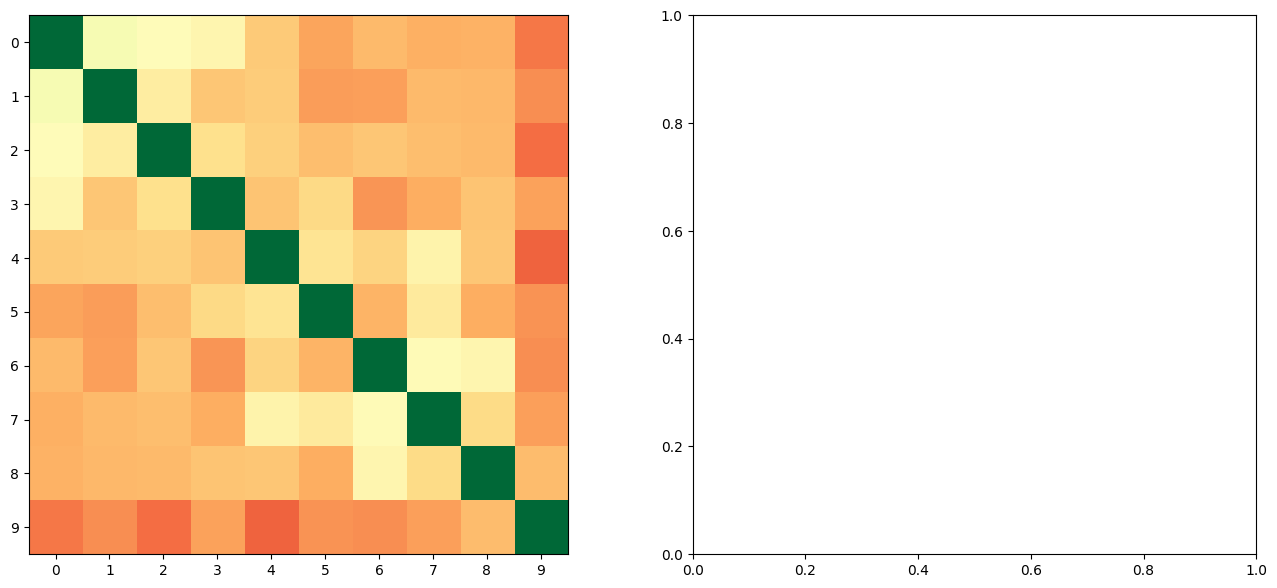

In [21]:
# PART 4: Visualize Embedding Relationships
# THE CHALLENGE WITH 1536 DIMENSIONS:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# We can't visualize 1536D space directly (humans can only see 2D/3D)
# 1. Similarity heatmap - show pairwise similarities (what we do here)
# WHY? Shows TRUE relationships without distortion
print("PART 4: Visualizing Similarity Relationships")
# Create similarity heatmap for top tickets
print("Creating similarity heatmap...")
# Select top matches and a few random others for comparison
selected_indices = list(top_indices[:5]) + list(np.random.choice(
    [i for i in range(len(tickets)) if i not in top_indices[:5]],
    size=min(5, len(tickets) - 5),
    replace=False
))


# Compute similarity matrix for selected tickets
selected_embeddings = embeddings[selected_indices]
similarity_matrix = cosine_similarity(selected_embeddings)
# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# Green = high similarity, Red = low similarity
im = ax1.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax1.set_xticks(range(len(selected_indices)))
ax1.set_yticks(range(len(selected_indices)))


In [22]:
# Label with ticket IDs and categories
labels = [f"{tickets[i]['ticket_id']}\n({tickets[i]['category']})"
          for i in selected_indices]
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(labels, fontsize=8)

[Text(0, 0, 'TICK-001\n(Authentication)'),
 Text(0, 1, 'TICK-011\n(Authentication)'),
 Text(0, 2, 'TICK-016\n(Authentication)'),
 Text(0, 3, 'TICK-006\n(Email)'),
 Text(0, 4, 'TICK-014\n(Authentication)'),
 Text(0, 5, 'TICK-017\n(Real-time)'),
 Text(0, 6, 'TICK-009\n(API)'),
 Text(0, 7, 'TICK-002\n(Database)'),
 Text(0, 8, 'TICK-008\n(File Upload)'),
 Text(0, 9, 'TICK-007\n(Search)')]

In [23]:
# Add similarity values to cells (so students can read exact numbers)
for i in range(len(selected_indices)):
    for j in range(len(selected_indices)):
        text = ax1.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

In [24]:
ax1.set_title('Similarity Heatmap: What Embeddings Actually Measure\n' +
             '(Top 5 matches + random others)', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax1, label='Cosine Similarity')

/tmp/ipykernel_1518/4126201131.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 1600x700 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax1, label='Cosine Similarity')


<Figure size 640x480 with 0 Axes>

In [25]:
# RIGHT PLOT: Query similarities bar chart
# Shows how similar each ticket is to the original query
query_similarities = [similarities[i] for i in selected_indices]
colors_bar = ['green' if i < 5 else 'gray' for i in range(len(selected_indices))]

ax2.barh(range(len(selected_indices)), query_similarities, color=colors_bar, alpha=0.7)
ax2.set_yticks(range(len(selected_indices)))
ax2.set_yticklabels([f"{tickets[i]['ticket_id']}" for i in selected_indices], fontsize=9)
ax2.set_xlabel('Similarity to Query', fontweight='bold')
ax2.set_title(f'Similarity Scores for Query:\n"{query}"\n(Green = Top 5 matches)',
             fontweight='bold', fontsize=11)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# Add score labels on bars
for i, score in enumerate(query_similarities):
    ax2.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('embeddings_similarity_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved as 'embeddings_similarity_analysis.png'")

✓ Visualization saved as 'embeddings_similarity_analysis.png'


<Figure size 640x480 with 0 Axes>

In [26]:
plt.show(block=False)

In [28]:
# PART 5: Experiment with Different Queries
print("PART 5: Try Different Queries")

test_queries = [
    "Database is timing out",
    "Payment not working for foreign customers",
    "App crashes on iPhone",
    "Emails are not being sent"
]

print("\nTesting semantic search with different queries:")
for test_query in test_queries:
    # Generate query embedding
    query_resp = client.embeddings.create(input=[test_query], model=embedding_model)
    query_emb = np.array([query_resp.data[0].embedding])

    # Compare to all tickets
    sims = cosine_similarity(query_emb, embeddings)[0]
    top_idx = np.argmax(sims)

    print(f"\nQuery: '{test_query}'")
    print(f"  → Best match: {tickets[top_idx]['title']}")
    print(f"  → Similarity: {sims[top_idx]:.4f}")


PART 5: Try Different Queries

Testing semantic search with different queries:

Query: 'Database is timing out'
  → Best match: Database connection timeout in production
  → Similarity: 0.5938

Query: 'Payment not working for foreign customers'
  → Best match: Payment processing fails for international cards
  → Similarity: 0.6145

Query: 'App crashes on iPhone'
  → Best match: Mobile app crashes on iOS 17
  → Similarity: 0.5880

Query: 'Emails are not being sent'
  → Best match: Email notifications not being delivered
  → Similarity: 0.6287
